# Run the script 

In [1]:
ls -lh $basepath/tables/*ecsv

ls: cannot access '/tables/*ecsv': No such file or directory


In [2]:
from brick2221.analysis.make_icecolumn_fig9 import makeplot, ok2221, pl

Set DATE-AVG to '2022-08-28T03:05:32.473' from MJD-AVG.
Set DATE-END to '2022-08-28T03:34:03.557' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -20.661125 from OBSGEO-[XYZ].
Set OBSGEO-H to 1526408297.850 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Loaded merged1182_daophot_basic_indivexp (2025-03-24 version)


min(dmag1) = 8.64222552010574e-06, max(dmag1) = 8.49236693866449
min(unextincted_1m2) = -2.570717355559952, max(unextincted_1m2) = 1.016675260026839
scatter plot of CO ice column vs F182M-F212N color: 1.4e+01 to 1.9e+01


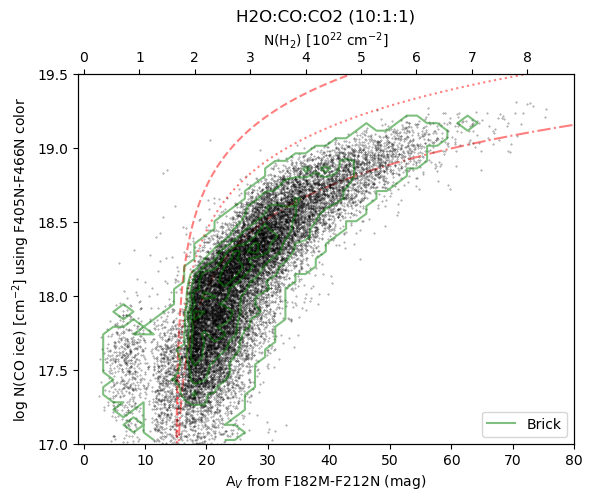

In [3]:
color_filter1 = 'F405N'
color_filter2 = 'F466N'
av, inferred_molecular_column, ax = makeplot(avfilts=['F182M', 'F212N'],
                                             sel=ok2221, ok=ok2221, ax=pl.figure().gca(), ylim=(17.0, 19.5),
                                             xlim=(-1, 80),
                                             plot_brandt=False,
         legend_kwargs={'loc': 'lower right'}, color_filter1=color_filter1, color_filter2=color_filter2)

min(dmag1) = 8.64222552010574e-06, max(dmag1) = 8.49236693866449
min(unextincted_1m2) = -2.570717355559952, max(unextincted_1m2) = 1.016675260026839
logy is not set, converting to 10^19 cm^-2 and using linear y-axis
scatter plot of CO ice column vs F182M-F212N color: 8.3e-06 to 1.3e+00


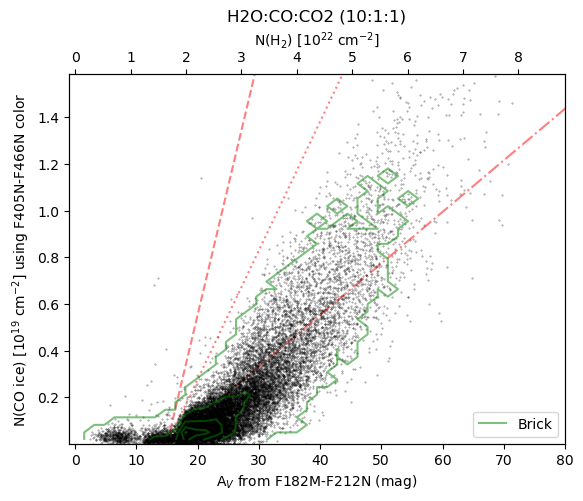

In [4]:
color_filter1 = 'F405N'
color_filter2 = 'F466N'
av, inferred_molecular_column, ax = makeplot(avfilts=['F182M', 'F212N'],
                                             sel=ok2221, ok=ok2221, ax=pl.figure().gca(), ylim=(16.0, 19.2),
                                             xlim=(-1, 80),
                                             plot_brandt=False,
                                             logy=False,
         legend_kwargs={'loc': 'lower right'}, color_filter1=color_filter1, color_filter2=color_filter2)

In [5]:
raise

RuntimeError: No active exception to reraise

In [ ]:
%run /orange/adamginsburg/jwst/brick/analysis/make_icecolumn_fig9.py

In [ ]:
raise "Don't rerun below"

# Below here are experiments

In [ ]:
dmag_tbl = Table.read(f'{basepath}/tables/H2O+CO_ice_absorption_tables.ecsv')
dmag_tbl.add_index('composition')

comp = 'H2O:CO (3:1)'
dmag_tbl.loc[comp]

av, cocol = makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='CO', abundance=1e-4,
         title=comp,
         dmag_tbl=dmag_tbl.loc[comp])
makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='H2O', abundance=10**-3.31,
         title=comp,
         dmag_tbl=dmag_tbl.loc[comp]);
Table([av, cocol], names=['A_V', 'N(CO)']).write('/orange/adamginsburg/jwst/brick/catalogs/ForBrandt_20250323.ecsv')

In [ ]:
dmag_tbl = Table.read(f'{basepath}/tables/H2O+CO_ice_absorption_tables.ecsv')
dmag_tbl.add_index('composition')
dmag_tbl.loc['H2O:CO (10:1)']

makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='CO', abundance=1e-4,
         title='H2O:CO (10:1)',
         dmag_tbl=dmag_tbl.loc['H2O:CO (10:1)'])
makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='H2O', abundance=10**-3.31,
         title='H2O:CO (10:1)',
         dmag_tbl=dmag_tbl.loc['H2O:CO (10:1)']);

In [ ]:
dmag_tbl = Table.read(f'{basepath}/tables/H2O_ice_absorption_tables.ecsv')
dmag_tbl.add_index('composition')

comp = 'H2O:CO2:CO (100:20:23)'
makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='CO', abundance=1e-4,
         title=comp,
         dmag_tbl=dmag_tbl.loc[comp])
makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='H2O', abundance=10**-3.31,
         title=comp,
         dmag_tbl=dmag_tbl.loc[comp]);

In [ ]:
dmag_h2o = Table.read(f'{basepath}/tables/H2O_ice_absorption_tables.ecsv')

dmag_h2o.add_index('composition')
dmag_h2o.add_index('temperature')
dmag_h2o.add_index('mol_id')

makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='H2O', abundance=4.89e-4,
         dmag_tbl=dmag_h2o.loc['H2O (1)'].loc['temperature', '25K'].loc['mol_id', 240])

In [ ]:
    dmag_co = Table.read(f'{basepath}/tables/CO_ice_absorption_tables.ecsv')
    dmag_co.add_index('composition')
    dmag_co.add_index('temperature')
    dmag_co.add_index('mol_id')

    makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
             icemol='CO', abundance=1e-4,
             title=dmag_co.loc['mol_id', 64].loc['composition', 'CO']['composition'][0],
             dmag_tbl=dmag_co.loc['mol_id', 64].loc['composition', 'CO'])
    pl.ylim(15, 22);


In [ ]:
dmag_co = Table.read(f'{basepath}/tables/CO_ice_absorption_tables.ecsv')
dmag_co.add_index('composition')
dmag_co.add_index('temperature')
dmag_co.add_index('mol_id')

dmag_tbl = dmag_co.loc['mol_id', 36].loc['composition', 'CO CO2 (100 70)']
makeplot(avfilts=['F182M', 'F212N'], sel=ok2221, ok=ok2221, ax=pl.figure().gca(),
         icemol='CO', abundance=1e-4,
         title=dmag_tbl['composition'][0],
         dmag_tbl=dmag_tbl)
pl.ylim(15, 22);
print("F410M absorption exceeds F466N absorption at some point - it flips back to red, which produces that artificial group up top")

In [ ]:
dmag_co.loc['mol_id', 36].loc['composition', 'CO CO2 (100 70)']['composition']

In [ ]:
basetable

In [ ]:
nirspec_dir = '/orange/adamginsburg/jwst/spectra/mastDownload/JWST/'
nirspecarchive_mags = Table.read(f'{nirspec_dir}/jwst_archive_spectra_as_fluxes.fits')
nirspecarchive_mags[:2]

In [ ]:
f182mf212 = nirspecarchive_mags['JWST/NIRCam.F182M'] - nirspecarchive_mags['JWST/NIRCam.F212N']
f212m466 = nirspecarchive_mags['JWST/NIRCam.F212N'] - nirspecarchive_mags['JWST/NIRCam.F466N']
sel = (f182mf212 > 2) & (f212m466 < 2.5)
nirspecarchive_mags[sel]['Target', 'Program', 'Object', 'SlitID', 'Observation', 'Visit', 'VisitGroup', 'Grating', 'Filename']